<a href="https://colab.research.google.com/github/broadinstitute/BE3D/blob/main/examples/BE3Dv9_MultiScreen_MEN1_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README
https://github.com/broadinstitute/BE3D

# Setup

In [ ]:
# @title Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# @title Install DSSP and ClustalO

! apt-get update
! apt-get install dssp clustalo


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,862 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 http:/

In [ ]:
# @title Install MUSCLE

! wget https://github.com/rcedgar/muscle/releases/download/v5.3/muscle-linux-x86.v5.3
! chmod +x muscle-linux-x86.v5.3
! mv muscle-linux-x86.v5.3 muscle


--2026-04-30 19:15:11--  https://github.com/rcedgar/muscle/releases/download/v5.3/muscle-linux-x86.v5.3
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/378508080/9dc41df9-b517-49e5-8af6-0cab933dbe43?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-30T20%3A04%3A30Z&rscd=attachment%3B+filename%3Dmuscle-linux-x86.v5.3&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-30T19%3A03%3A50Z&ske=2026-04-30T20%3A04%3A30Z&sks=b&skv=2018-11-09&sig=lhz4obzKKFCtqjzdg8E5R71wwdUZXvsvrcUGCTjbUKQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzU3NjgxMSwibmJmIjoxNzc3NTc2NTExLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGl

In [ ]:
# @title Install BE3D

! pip install git+https://github.com/broadinstitute/beclust3d-public.git
print('beclust3d installed at:')
! pip show beclust3d


  Cloning https://github.com/broadinstitute/beclust3d-public.git to /tmp/pip-req-build-q9gobqei
  Running command git clone --filter=blob:none --quiet https://github.com/broadinstitute/beclust3d-public.git /tmp/pip-req-build-q9gobqei
  Resolved https://github.com/broadinstitute/beclust3d-public.git to commit d5d89c2488e97eb00497a8f3edeede2b71233e6a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 837.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 13.0 MB/s eta 0:00:00
  Created wheel for beclust3d: filename=beclust3d-1.0.0-py3-none-any.whl size=764617 sha256=24de7593e64c44055e1c6b7c7d2a92fa1a24fb0855fb4427a3b7b4dc4ffe2d80
  Stored in directory: /tmp/pip-ephem-wheel-cache-prm5qy19/wheels/f1/a7/29/932b67d47922e277bd8c92943ec17ff5105d711c221cc4f642
  Created wheel for wget: filenam

In [ ]:
# @title Import packages

import os
import sys
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import uuid
import ipywidgets as widgets
from IPython.display import display

from IPython.display import Image, display, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from google.colab import files
import shutil

from beclust3d import *

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

plt.rcParams['font.family'] = 'DejaVu Sans'


In [ ]:
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py -O be3d_display_yaml.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py -O be3d_helper.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_qa.py -O be3d_qa.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_calculate_lfc3d.py -O beclust3d_calculate_lfc3d.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_nonaggregate.py -O beclust3d_nonaggregate.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_characterization.py -O beclust3d_characterization.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/bemetaclust3d_metaaggregate.py -O bemetaclust3d_metaaggregate.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/bemetaclust3d_characterization.py -O bemetaclust3d_characterization.py


--2026-04-30 19:15:47--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18139 (18K) [text/plain]
Saving to: ‘be3d_display_yaml.py’

be3d_display_yaml.p 100%[===================>]  17.71K  --.-KB/s    in 0.004s  

2026-04-30 19:15:47 (4.10 MB/s) - ‘be3d_display_yaml.py’ saved [18139/18139]

--2026-04-30 19:15:48--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting resp

# BE3D Inputs (MEN1)

In [ ]:
# @title Download relevant files for MEN1

! mkdir MEN1/
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/yaml/MEN1-Perner2023.yaml -O MEN1/MEN1-Perner2023.yaml
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/men1.fasta -O MEN1/men1.fasta
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/pdb/men1.pdb -O MEN1/men1.pdb
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/PernerNature2023-MOLM13-Screen.tsv -O MEN1/PernerNature2023-MOLM13-Screen.tsv
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/PernerNature2023-MV411-Screen.tsv -O MEN1/PernerNature2023-MV411-Screen.tsv


--2026-04-30 19:17:31--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/yaml/MEN1-Perner2023.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7159 (7.0K) [text/plain]
Saving to: ‘MEN1/MEN1-Perner2023.yaml’

MEN1/MEN1-Perner202 100%[===================>]   6.99K  --.-KB/s    in 0s      

2026-04-30 19:17:32 (61.3 MB/s) - ‘MEN1/MEN1-Perner2023.yaml’ saved [7159/7159]

--2026-04-30 19:17:32--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/men1.fasta
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent,

In [ ]:
# @title Display Input .yaml File

from be3d_display_yaml import display_yaml_config

# @markdown Path to downloaded or user-input .yaml configuration file
yaml_config_filepath = "MEN1/MEN1-Perner2023.yaml" # @param {type:"string"}
display_yaml_config(yaml_config_filepath)

with open(yaml_config_filepath, 'r') as file:
    input_dict = yaml.safe_load(file)

output_dir = input_dict['output_dir']
input_gene = input_dict['input_gene']

# @markdown To edit BE3D inputs, open the Files tab, open the yaml config file, change the variables, and save the file.


# BE3D Run (MEN1)

MEN1/MEN1-Perner2023.yaml and /content/MEN1/MEN1-Perner2023.yaml are the same file.
All results will be saved in the following directory: /content/MEN1/
Output from beclust3d.lfc3d.structure is saved in the following directory: /content/MEN1/sequence_structure/
Output from beclust3d.qa.hypothesis_tests is saved in the following directory: /content/MEN1/hypothesis_qa/
BE-QA complete: sequence/structural features and hypothesis tests


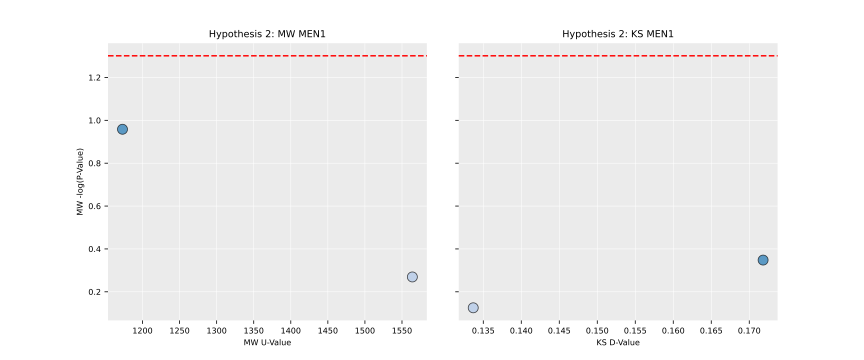

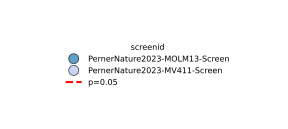

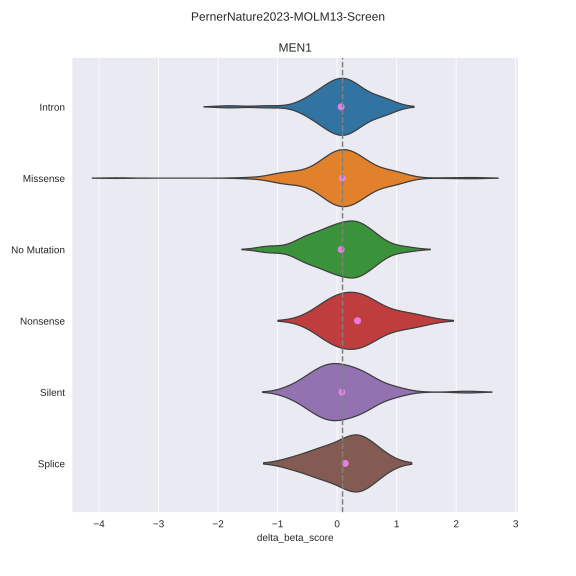

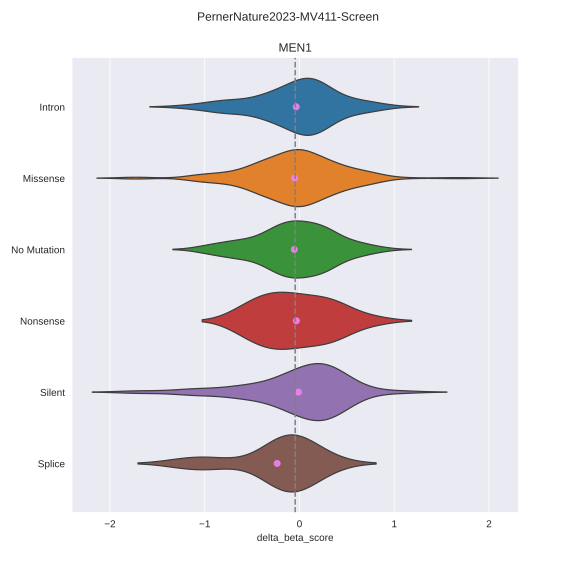

In [ ]:
# @title BE-QA and Visualizations
# @markdown Description

! python be3d_qa.py {yaml_config_filepath}

display(SVG(filename=f'{output_dir}hypothesis_qa/hypothesis2_scatterplot_by_screenid.svg'))
display(SVG(filename=f'{output_dir}hypothesis_qa/hypothesis2_legend_by_screenid.svg'))

screen_name = 'PernerNature2023-MOLM13-Screen'
display(SVG(filename=f'{output_dir}screendata/plots/{screen_name}_violinplot_by_muttype.svg'))
screen_name = 'PernerNature2023-MV411-Screen'
display(SVG(filename=f'{output_dir}screendata/plots/{screen_name}_violinplot_by_muttype.svg'))


## BE-Clust3D and Visualizations

In [ ]:
# @title BE-Clust3D
# @markdown Description

! python beclust3d_calculate_lfc3d.py {yaml_config_filepath}
! python beclust3d_nonaggregate.py {yaml_config_filepath}

In [ ]:
# @title Visualization (select a screen)
# @markdown Choose a screen from the dropdown to view its LFC, LFC3D, and cluster plots.

import os
from ipywidgets import interact, Dropdown

screen_names = [os.path.splitext(os.path.basename(s))[0] for s in input_dict['screens']]

def show_lfc3d(screen_name):
    for path in [
        f'{output_dir}LFC/plots/{input_gene}_{screen_name}_LFC_cutoff05_scatter_cutoff.svg',
        f'{output_dir}LFC3D/plots/{input_gene}_{screen_name}_LFC3D_cutoff05_scatter_cutoff.svg',
        f'{output_dir}cluster_LFC3D/plots/{input_gene}_{screen_name}_LFC3D_Positive_Dendrogram_p<0.001_6A.svg',
    ]:
        display(SVG(filename=path)) if os.path.exists(path) else print(f'[not found] {path}')

interact(show_lfc3d, screen_name=Dropdown(options=screen_names, description='Screen:'));

## BEClust3D Characterization and Visualizations

In [ ]:
# @title BEClust3D Characterization

! python beclust3d_characterization.py {yaml_config_filepath}

In [ ]:
# @title Visualization (select a screen)
# @markdown Choose a screen from the dropdown to view its characterization plots.

import os
from ipywidgets import interact, Dropdown

screen_names = [os.path.splitext(os.path.basename(s))[0] for s in input_dict['screens']]

def show_characterization(screen_name):
    for path in [
        f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_05_{screen_name}.png',
        f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter_{screen_name}.png',
        f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_05_{screen_name}.png',
        f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_05_{screen_name}.png',
    ]:
        display(Image(filename=path)) if os.path.exists(path) else print(f'[not found] {path}')

interact(show_characterization, screen_name=Dropdown(options=screen_names, description='Screen:'));

## BE-MetaClust3D and Visualizations

In [ ]:
# @markdown Description

! python bemetaclust3d_metaaggregate.py {yaml_config_filepath}

# display(SVG(filename=f'{output_dir}meta-aggregate/plots/{input_gene}_LFC_cutoff05_scatter_cutoff.svg'))
display(SVG(filename=f'{output_dir}meta-aggregate/plots/{input_gene}_LFC3D_cutoff05_scatter_cutoff.svg'))
display(SVG(filename=f'{output_dir}cluster_LFC3D/plots/{input_gene}_Meta_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))

--2026-04-30 19:15:47--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18139 (18K) [text/plain]
Saving to: ‘be3d_display_yaml.py’

be3d_display_yaml.p 100%[===================>]  17.71K  --.-KB/s    in 0.004s  

2026-04-30 19:15:47 (4.10 MB/s) - ‘be3d_display_yaml.py’ saved [18139/18139]

--2026-04-30 19:15:48--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting resp

## BE-MetaClust3D Characterization and Visualizations

In [ ]:
! python bemetaclust3d_characterization.py {yaml_config_filepath}

display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_05_Meta.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_05.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_05.png'))

--2026-04-30 19:15:47--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18139 (18K) [text/plain]
Saving to: ‘be3d_display_yaml.py’

be3d_display_yaml.p 100%[===================>]  17.71K  --.-KB/s    in 0.004s  

2026-04-30 19:15:47 (4.10 MB/s) - ‘be3d_display_yaml.py’ saved [18139/18139]

--2026-04-30 19:15:48--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting resp

# G2P Visualizations

The steps below map your BE3D results onto an interactive 3D protein structure using the [Genomics 2 Proteins (G2P) portal](https://g2p.broadinstitute.org). You will download the BE3D output files, upload them to the portal, and explore base-editing scores and clusters directly on the structure.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, FileLink
import os
import shutil
from google.colab import files

def download_files_button(path):
    output_filename = f"{os.path.basename(path)}_files.zip"
    shutil.make_archive(output_filename.replace('.zip', ''), 'zip', path)

    print(f"Created {output_filename}. Click the button to download.")

    button = widgets.Button(description=f"Download {output_filename}")
    output = widgets.Output()

    def on_button_clicked(b):
        with output:
            files.download(output_filename)

    button.on_click(on_button_clicked)
    display(button, output)

In [ ]:
# @title 1. Download the G2P visualization files
# @markdown Run this cell, then click the button to download the BE3D output files prepared for G2P.
download_files_button('/content/MEN1/g2p_visualization')

In [ ]:
# @title 2. Open the G2P portal interactive module
# @markdown 1. Go to https://g2p.broadinstitute.org
# @markdown 2. Click **Interactive Module**

from IPython.display import Image
Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/2_g2p.png", width=600)

In [ ]:
# @title 3. Start the structure-mapping workflow
# @markdown Click **Start with a gene/protein identifier** to map BE3D results onto a 3D structure using G2P.
Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/3_select_first_interactive_module.png", width=600)

In [ ]:
# @title 4. Select a gene
# @markdown Enter a gene name and click **Proceed**.
Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/4_select_a_gene.png", width=600)

In [ ]:
# @title 5. Select a protein structure
# @markdown Choose a 3D protein structure from the PDB, AlphaFold, or your own uploaded structure.
Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/5_select_a_pdb.png", width=600)

In [ ]:
# @title 6. Upload your BE3D results (.tsv)
# @markdown Click **Upload your data** and select the BE3D results file downloaded in step 1.
Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/6_upload_BE3D_tsv.png", width=600)

In [ ]:
# @title 7. Filter the columns of interest
# @markdown 1. Click **Filter Columns** and keep the columns you want to visualize.
# @markdown 2. Set the data type to **features** for any `... hit cluster` column.

Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/7_filter_columns.png", width=600)

In [ ]:
# @title 8. Explore the visualization
# @markdown Your BE3D scores and clusters are now mapped onto the 3D structure — rotate, zoom, and explore.
Image(url="https://raw.githubusercontent.com/broadinstitute/BE3D/main/examples/imgs/8_done.png", width=600)